# Exploratory Visualization of Transcriptomic Data
**Author**: João Guilherme Mendes (joaoguilhermemendes@id.uff.br)

---

**Exploratory visualization and quality assessment of the transcriptomic expression matrix generated**

**Goal**: Explore the transcriptomic dataset through visual analysis and identify general expression patterns, sample similarities, and potential outliers.

---

After preprocessing and cleaning the RNA-seq dataset, the next step was to explore the gene expression data by visualizations.

RNA-seq datasets usually contain thousands of genes and highly variable expression values. Most genes have low expression levels, while a small number of genes are highly expressed. Because of this, raw TPM values are often difficult to interpret directly.

In this notebook, visualizations will be used to:
- compare raw and log-transformed expression values
- inspect expression distributions across samples
- analyze similarity between samples
- identify possible outliers
- explore transcriptomic patterns using PCA

These analyses help better understand the dataset before downstream analyses such as differential gene expression and machine learning.

---

## Log2 Transformation of Gene Expression Values

Although TPM normalization makes expression values comparable across samples, the resulting distributions remain highly asymmetric. A small number of highly expressed genes dominate the dataset, inflating variance.

In [11]:
import pandas as pd
import numpy as np

tpm_matrix = pd.read_csv("../data/processed/expression_matrix_tpm.csv")
numeric_df = tpm_matrix.select_dtypes(include='number')

sample_stats = pd.DataFrame({
    "mean": numeric_df.mean(),
    "median": numeric_df.median(),
    "std": numeric_df.std()
}).T

sample_stats

,HCB1-21,HCB2-21,HCB3-21,HCB5-21,HCB6-21,HCB7-21,HCB8-21,HCB9-21,HCB10-21,HCB11-21,...,PTB4-21,PTB5-21,PTB6-21,PTB7-21,PTB8-21,PTB9-21,PTB10-21,PTB11-21,PTB12-21,PTB13-21
mean,60.088919,60.081313,60.085312,60.085868,60.08539,60.085218,60.087587,60.083783,60.088917,60.088929,...,60.055171,60.083053,60.082770,60.082595,60.084334,60.083802,60.08389,60.083075,60.080856,60.083126
median,8.930000,5.710000,7.535000,7.350000,7.04000,6.970000,9.890000,9.540000,6.925000,7.665000,...,6.370000,8.480000,10.900000,7.920000,9.265000,7.110000,4.04000,7.745000,4.590000,6.400000
std,384.631458,482.738696,374.348316,419.664424,432.09946,506.796312,367.397994,377.431645,451.806542,432.461778,...,582.966991,420.445508,360.658649,515.312545,374.756529,507.223297,1200.97429,1057.480662,2384.728099,717.453518


To reduce this effect, a log2(TPM + 1) transformation was applied:

In [36]:
log_df = np.log2(numeric_df + 1)
log_df.describe().T

,count,mean,std,min,25%,50%,75%,max
HCB1-21,16642.0,3.233723,2.515956,0.0,0.680319,3.311794,5.055608,14.064771
HCB2-21,16642.0,2.985900,2.486042,0.0,0.622930,2.746313,4.677508,14.697349
HCB3-21,16642.0,3.154366,2.515573,0.0,0.704872,3.093391,4.945795,14.048401
HCB5-21,16642.0,3.121350,2.491040,0.0,0.687061,3.061776,4.860839,14.197265
HCB6-21,16642.0,3.093662,2.440399,0.0,0.765535,3.007196,4.772414,14.093326
HCB7-21,16642.0,3.051851,2.417844,0.0,0.722466,2.994580,4.731183,14.802823
HCB8-21,16642.0,3.320707,2.500803,0.0,0.831877,3.444931,5.145983,14.011523
HCB9-21,16642.0,3.284028,2.491754,0.0,0.807355,3.397803,5.079805,13.942104
HCB10-21,16642.0,3.053796,2.440071,0.0,0.689294,2.986411,4.738768,14.455334
HCB11-21,16642.0,3.145087,2.452476,0.0,0.765535,3.115200,4.860466,14.396928


After the transformation, the data becomes more suitable for analyses such as correlation, PCA, clustering, and downstream machine learning workflows.

---

## Distribution of Raw and Log-Transformed Expression Values

To better understand the dataset, histograms were generated using both raw TPM values and log-transformed expression values.

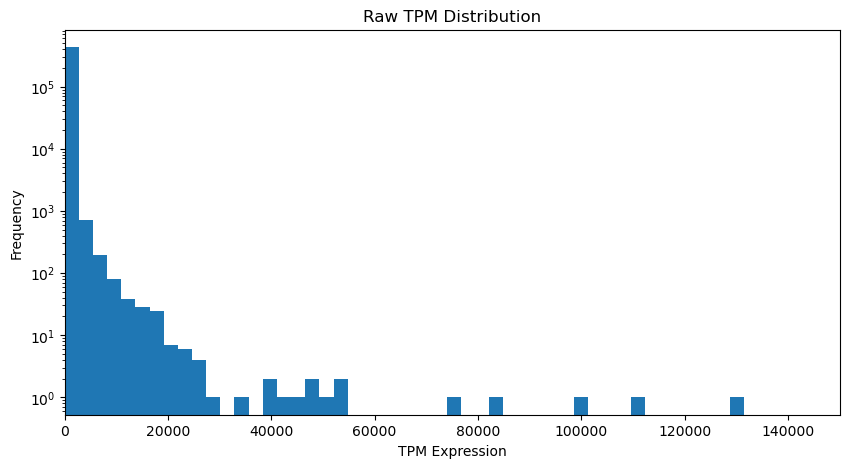

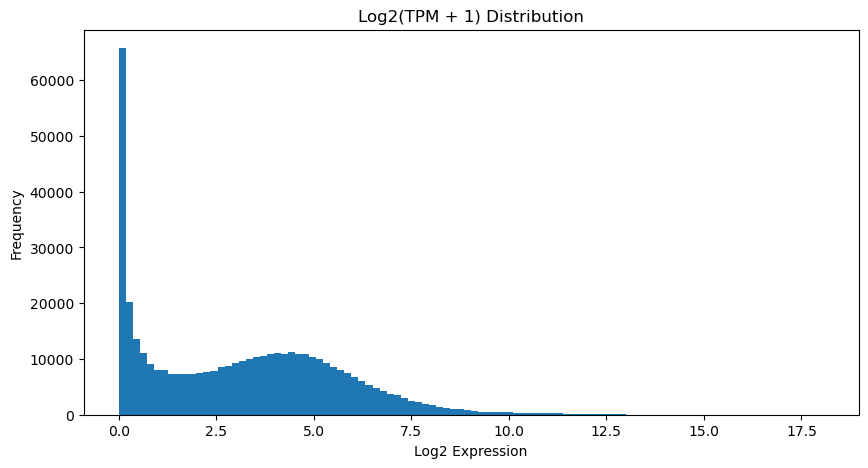

In [49]:
import matplotlib.pyplot as plt

# Flatten transforma toda a matriz em um vetor gigante
raw_values = numeric_df.values.flatten()
log_values = log_df.values.flatten()

# Antes da transformação
plt.figure(figsize=(10,5))
plt.hist(raw_values, bins=100)
plt.title("Raw TPM Distribution")
plt.xlabel("TPM Expression")
plt.ylabel("Frequency")
plt.xlim(0, 150000)
plt.yscale('log')
plt.show()

# Depois da transformação
plt.figure(figsize=(10,5))
plt.hist(log_values, bins=100)
plt.title("Log2(TPM + 1) Distribution")
plt.xlabel("Log2 Expression")
plt.ylabel("Frequency")
plt.show()

The raw RNA-seq data showed a highly skewed distribution, where most genes presented low expression levels while a small number of genes showed extremely high expression values. This makes the raw data difficult to interpret directly.

After applying the log2(TPM + 1) transformation, the distribution became more compressed and balanced, reducing the effect of extreme values and making the dataset easier to analyze and compare across samples.

Comparing the distributions before and after transformation helps visualize the impact of log-scaling on the transcriptomic data.

---

## Distribution of Log-Transformed Expression Across Samples

Boxplots were used to compare the distribution of log-transformed gene expression values across all samples.

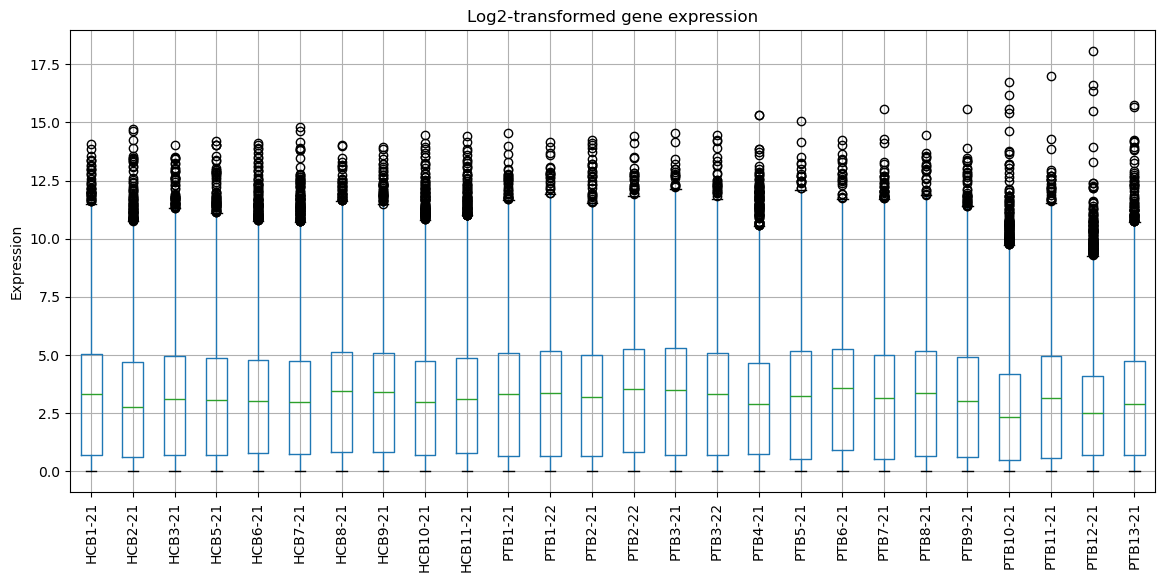

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
log_df.boxplot(rot=90)
plt.title("Log2-transformed gene expression")
plt.ylabel("Expression")
plt.show()


After preprocessing and log transformation, most samples showed relatively similar distributions, suggesting that the normalization process reduced extreme variation in the dataset. This visualization also helps identify samples with unusual variability or shifted distributions that may represent potential outliers or technical differences requiring further investigation.


---

## Density Plot of Gene Expression Distributions

Density plots were generated using the log-transformed expression values to compare the overall distribution of gene expression across samples.

Compared to histograms, density plots provide a smoother visualization and make it easier to compare multiple samples at the same time.

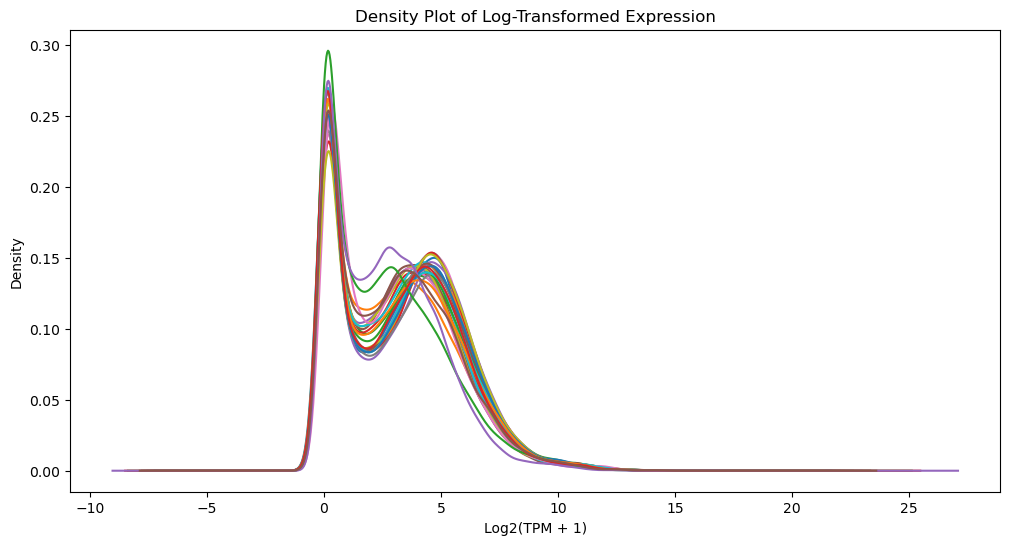

In [25]:
plt.figure(figsize=(12,6))

for column in log_df.columns:
    log_df[column].plot(kind='density')

plt.title("Density Plot of Log-Transformed Expression")
plt.xlabel("Log2(TPM + 1)")
plt.ylabel("Density")

plt.show()


Most samples showed relatively similar distribution patterns after normalization and log transformation, suggesting that the preprocessing steps reduced extreme technical variation. Samples with noticeably different curves may represent potential outliers or biological differences that should be investigated further.

The large peak near zero reflects the high number of lowly expressed genes commonly observed in RNA-seq datasets.

---

## Correlation Heatmap Between Samples

A correlation heatmap was generated using the log-transformed expression values to compare transcriptomic similarity across samples.

In this visualization, higher correlation values indicate samples with more similar global gene expression patterns, while lower values suggest greater transcriptomic differences.

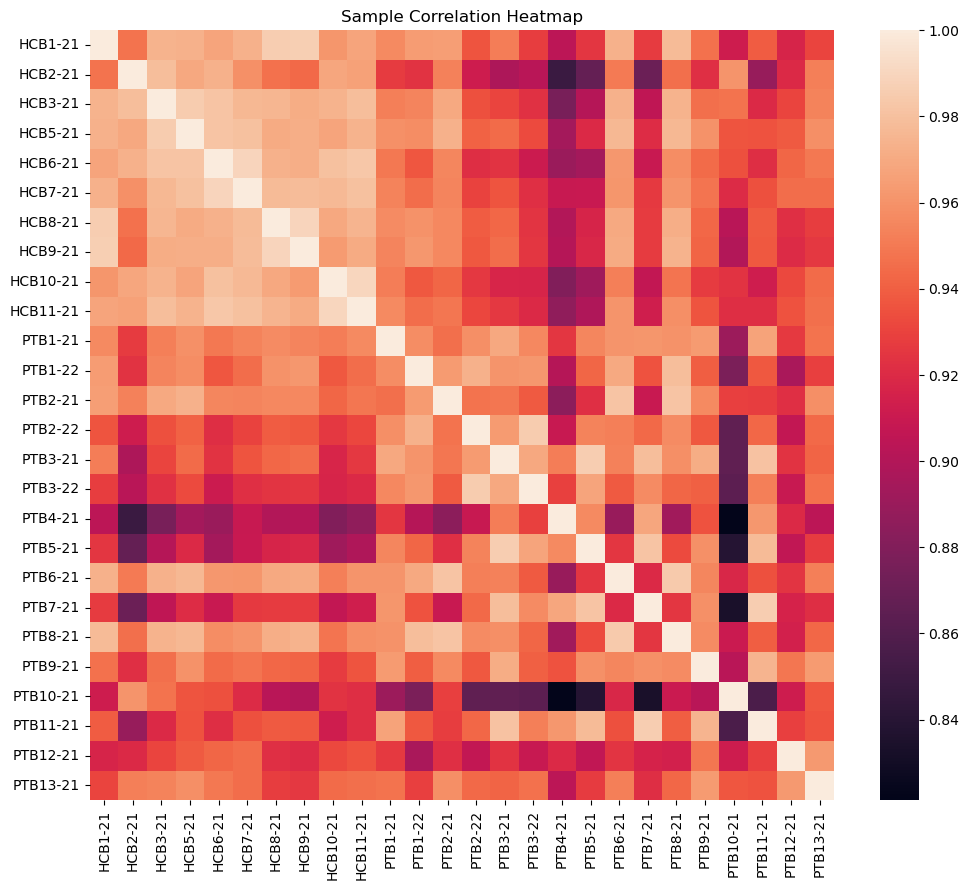

In [26]:
import seaborn as sns

correlation_matrix = log_df.corr()

plt.figure(figsize=(12,10))

sns.heatmap(correlation_matrix)

plt.title("Sample Correlation Heatmap")

plt.show()

Healthy control samples (HCB) appeared to have more similar expression patterns, while dengue samples (PTB) showed greater variability across the dataset.

Some samples, especially PTB4-21 and PTB10-21, presented more distinct correlation patterns compared to the other samples. These differences may reflect biological variability or possible technical differences identified during preprocessing and exploratory analysis.

---

## Principal Component Analysis (PCA)

Principal Component Analysis (PCA) was used to reduce the dimensionality of the transcriptomic dataset and visualize global expression patterns across samples.

Because RNA-seq datasets contain thousands of genes, PCA helps simplify the data by projecting samples into a lower-dimensional space. In the PCA plot, samples with similar expression profiles tend to appear closer together.

Before applying PCA, the data was standardized to reduce the effect of genes with very large variances.

This analysis helps explore overall sample similarity, possible group separation between controls and dengue patients, and potential outlier samples.

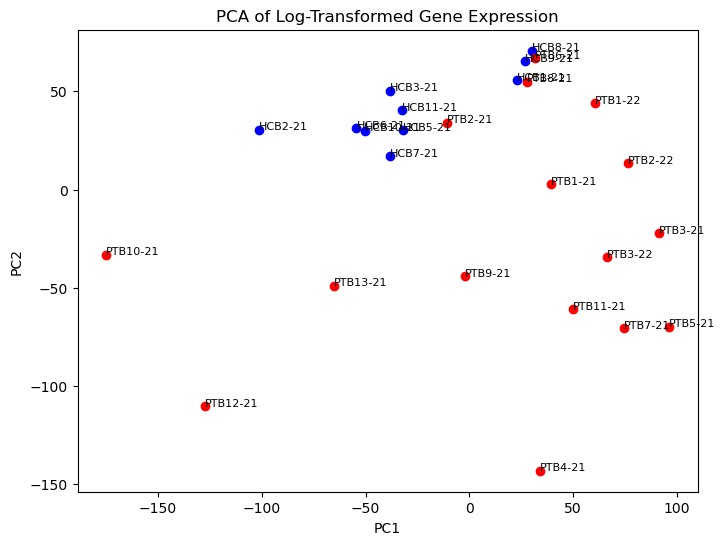

In [35]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

groups = []

for sample in X.index:
    if sample.startswith("HCB"):
        groups.append("Control")
    else:
        groups.append("Dengue")

colors = {
    "Control": "blue",
    "Dengue": "red"
}

# Transpor: samples viram linhas
X = log_df.T

# Escalonar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

for i, sample in enumerate(X.index):
    plt.scatter(
        pca_result[i,0],
        pca_result[i,1],
        color=colors[groups[i]]
    )

    plt.text(
        pca_result[i,0],
        pca_result[i,1],
        sample,
        fontsize=8
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Log-Transformed Gene Expression")

plt.show()

The PCA projection showed partial separation between healthy control samples (HCB) and dengue patient samples (PTB), suggesting the presence of transcriptomic differences between the groups.

Healthy controls appeared more closely grouped together, while dengue samples showed greater variability across the PCA space. This may reflect biological differences between patients, such as immune response variation or disease severity.

Some samples, especially PTB4-21, PTB10-21, and PTB12-21, appeared more distant from the main clusters. These same samples also showed unusual behavior in previous analyses, including the correlation heatmap and descriptive statistics, suggesting they may represent potential outliers or biologically distinct profiles.

Interestingly, the original study also reported lower gene mapping ratios for PTB4-21 and PTB12-21 during RNA-seq processing, which may help explain their distinct behavior across the exploratory analyses.

---

### Next Step...

In `04_Differential_Expression.ipynb`, the log-transformed transcriptomic data will be analyzed to identify genes differentially expressed between healthy controls and dengue samples through statistical analysis and fold-change comparison.